# Phân loại người sống sót trên tàu Titanic


![Titanic](header.png "Titanic")

## Ôn tập
Trong phần trước, chúng ta đã tiến hành các bước sau:
1. Định nghĩa vấn đề
    - Mô tả vấn đề
    - Xác định đầu vào, đầu ra, loại bài toán
2. Chuẩn bị vấn đề:
    - Tải thư viện và dữ liệu
3. Phân tích dữ liệu:
    - Hiển thị thông tin dữ liệu
    - Thông tin thống kê trên các thuộc tính dữ liệu
    - Mối tương quan giữa các thuộc tính
4. Chia dữ liệu
5. Chuẩn bị dữ liệu:
    - Làm sạch dữ liệu (tạo bảng dữ liệu chỉ có thuộc tính nhập, xuất, xử lý dữ liệu thiếu và trùng lặp)
    - Biến đổi dữ liệu (label encoder, onehot encoder, chuẩn hóa)


**Kết quả**:

- feature1:

    - scale_columns.npz (chứa cột biến đổi)
    - class_encoder.joblib

    - Feature MinMax:

        - minmax_scaler.joblib
        - feat_minmax.npz
        - df_minmax.xlsx
    - Feature Standard:

        - standard_scaler.joblib
        - feat_standard.npz
        - df_standard.xlsx

## Khởi tạo thí nghiệm


### Khai báo thư viện

In [1]:
# Load libraries
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold,RandomizedSearchCV

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### Tham số thực nghiệm

Sử dụng biến dạng dict để lưu các tham số cấu hình cần thiết cho quá trình huấn luyện

In [3]:
params = {}

params["exps_dir"]  = "../../exps" #tùy vào luu trữ của mỗi người tùy chỉnh lại đường dẫn này
params["exp_name"]  = "Titanic_Survival_02_standard"

params["exps_root"] = f'{params["exps_dir"]}/result1_standard'
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

params["survived_encoder_path"] = f'{params["exps_dir"]}/feature1/survived_encoder.joblib'


params["data_path"] = f'{params["exps_dir"]}/feature1/df_standard.xlsx'

params["k_fold"] = 5
params["random_state"] = 42

print("params: ")
for k in params: print(f'+ {k}: {params[k]}')

# cố định random-state để phục hồi lại kết quả thí nghiệm
random.seed(params["random_state"])
os.environ['PYTHONHASHSEED'] = str(params["random_state"])
np.random.seed(params["random_state"])

params: 
+ exps_dir: ../../exps
+ exp_name: Titanic_Survival_02_standard
+ exps_root: ../../exps/result1_standard
+ save_dir: ../../exps/result1_Titanic_Survival_02_standard
+ survived_encoder_path: ../../exps/feature1/survived_encoder.joblib
+ data_path: ../../exps/feature1/df_standard.xlsx
+ k_fold: 5
+ random_state: 42


## 5. Dữ liệu kiểm nghiệm (Validation Dataset)

Chúng ta chuẩn bị dữ liệu kiểm nghiệm theo phương pháp hold-out:
+ Tập dữ liệu được chia thành 2 phần train/test với tỉ lệ 7/3 (đã làm trước)
+ Tập train sẽ được dùng để huấn luyện, điều chỉnh tham số với chiến lược:
    + Hold-out (tiếp tục chia 7/3 với train/valid)
    + k-fold (chia thành k phần đều nhau với k-1 phần cho train/1 phần cho valid)
    + Trong đó, train là dùng huấn luyện và valid dùng điều chỉnh tham số
+ Tập test dùng để kiểm nghiệm lại độ hiệu quả của thuật toán sau khi chọn mô hình tối ưu

In [4]:
# Tải thông tin dữ liệu
df_data   = pd.read_excel(params["data_path"])

print(f'Data path [{params["data_path"]}]')
display.display(df_data)

Data path [../../exps/feature1/df_standard.xlsx]


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,0,3,1,0.271174,0.125,0.000000,0.014151,2,0.1,3,2
1,1,1,0,0.472229,0.125,0.000000,0.139136,0,0.1,3,3
2,1,3,0,0.321438,0.000,0.000000,0.015469,2,0.0,0,1
3,1,1,0,0.434531,0.125,0.000000,0.103644,2,0.1,3,3
4,0,3,1,0.434531,0.000,0.000000,0.015713,2,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,0.334004,0.000,0.000000,0.025374,2,0.0,0,4
887,1,1,0,0.233476,0.000,0.000000,0.058556,2,0.0,0,1
888,0,3,0,0.346569,0.125,0.333333,0.045771,2,0.3,3,1
889,1,1,1,0.321438,0.000,0.000000,0.058556,0,0.0,0,2


In [5]:
# Chia dữ liệu thành trường input/output
X_train = df_data.drop(columns=["Survived"]).values
y_train = df_data["Survived"].values.astype(int)


In [6]:
print(f'+ x_shape: {X_train.shape}, y_shape: {y_train.shape}')
print(f'+ Input:\n{X_train[:20, :]}')
print(f'+ Output:\n{y_train[:20]}')

+ x_shape: (891, 10), y_shape: (891,)
+ Input:
[[3.         1.         0.27117366 0.125      0.         0.01415106
  2.         0.1        3.         2.        ]
 [1.         0.         0.4722292  0.125      0.         0.13913574
  0.         0.1        3.         3.        ]
 [3.         0.         0.32143755 0.         0.         0.01546857
  2.         0.         0.         1.        ]
 [1.         0.         0.43453129 0.125      0.         0.1036443
  2.         0.1        3.         3.        ]
 [3.         1.         0.43453129 0.         0.         0.01571255
  2.         0.         0.         2.        ]
 [3.         1.         0.34656949 0.         0.         0.0165095
  1.         0.         0.         2.        ]
 [1.         1.         0.67328474 0.         0.         0.10122886
  2.         0.         0.         2.        ]
 [3.         1.         0.01985423 0.375      0.16666667 0.04113566
  2.         0.4        2.         0.        ]
 [3.         0.         0.33400352 

## 6. Lượng giá thuật toán (Evaluate Algorithms)

### 6.1. Baselines

- Để tránh tường hợp tập validation chỉ toàn các giá trị trùng nhau ở cột **Survived** ta sẽ dùng StratifiedKFold thay vì Fold như thông thường.
- Giúp mỗi fold đại diện tốt hơn cho toàn bộ tập dữ liệu.

In [7]:
kfold = StratifiedKFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"Fold {fold}: train={len(train_idx)}, valid={len(valid_idx)}")
    #display.display(f'+ train_idx: {train_idx}')
    #display.display(f'+ valid_idx: {valid_idx}')
    display.display(f'+ train/valid size: {len(train_idx)} / {len(valid_idx)}')
    pass

+ X_train: 891
Fold 0: train=712, valid=179


'+ train/valid size: 712 / 179'

Fold 1: train=713, valid=178


'+ train/valid size: 713 / 178'

Fold 2: train=713, valid=178


'+ train/valid size: 713 / 178'

Fold 3: train=713, valid=178


'+ train/valid size: 713 / 178'

Fold 4: train=713, valid=178


'+ train/valid size: 713 / 178'

In [8]:
X_train[[0, 2, 10]]

array([[3.        , 1.        , 0.27117366, 0.125     , 0.        ,
        0.01415106, 2.        , 0.1       , 3.        , 2.        ],
       [3.        , 0.        , 0.32143755, 0.        , 0.        ,
        0.01546857, 2.        , 0.        , 0.        , 1.        ],
       [3.        , 0.        , 0.04498618, 0.125     , 0.16666667,
        0.03259623, 2.        , 0.2       , 3.        , 1.        ]])

In [9]:
y_train[[0,2,10]]

array([0, 1, 1])

Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.7821229050279329, 0.7865168539325843, 0.8033707865168539, 0.8089887640449438, 0.8426966292134831]
+ mean_acc = 0.804739 +/- 0.021467

Confusion matrix on training set for [LR]:


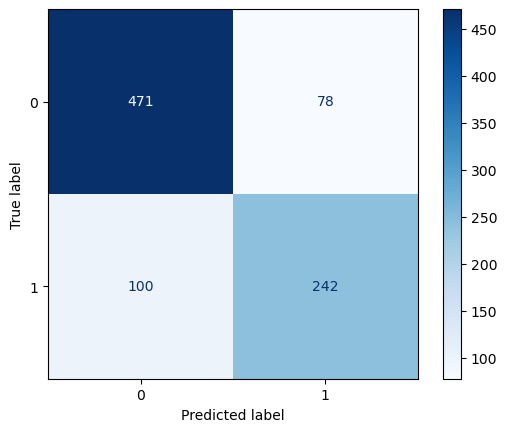

Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.7821229050279329, 0.7865168539325843, 0.797752808988764, 0.7865168539325843, 0.8426966292134831]
+ mean_acc = 0.799121 +/- 0.022394

Confusion matrix on training set for [LDA]:


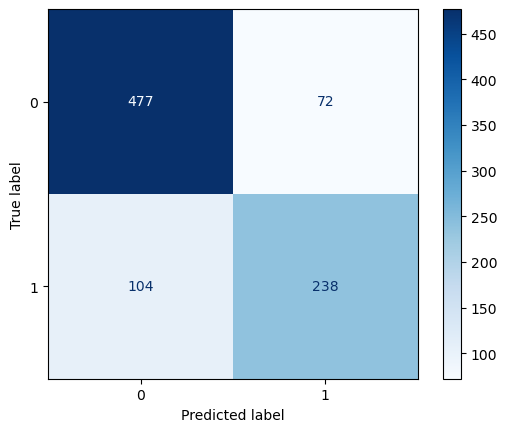

Model [KNN]:
+ params = {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
+ acc = [0.8212290502793296, 0.8033707865168539, 0.7696629213483146, 0.8314606741573034, 0.7921348314606742]
+ mean_acc = 0.803572 +/- 0.021773

Confusion matrix on training set for [KNN]:


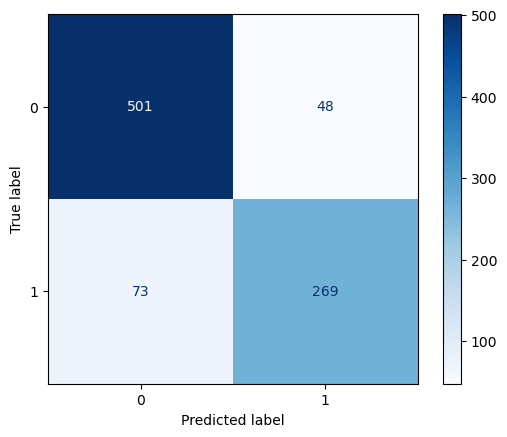

Model [CART]:
+ params = {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
+ acc = [0.776536312849162, 0.8033707865168539, 0.7303370786516854, 0.7584269662921348, 0.8089887640449438]
+ mean_acc = 0.775532 +/- 0.029088

Confusion matrix on training set for [CART]:


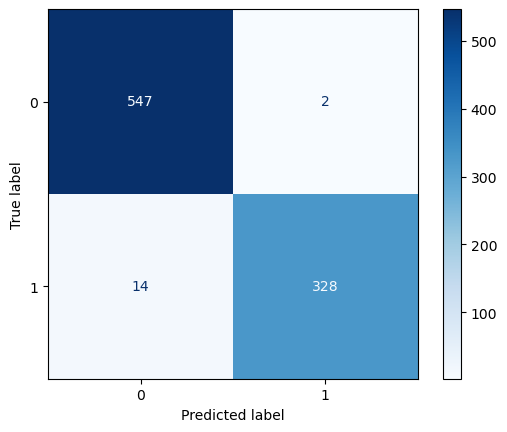

Model [NB]:
+ params = {'priors': None, 'var_smoothing': 1e-09}
+ acc = [0.7877094972067039, 0.8033707865168539, 0.7865168539325843, 0.8033707865168539, 0.8033707865168539]
+ mean_acc = 0.796868 +/- 0.007973

Confusion matrix on training set for [NB]:


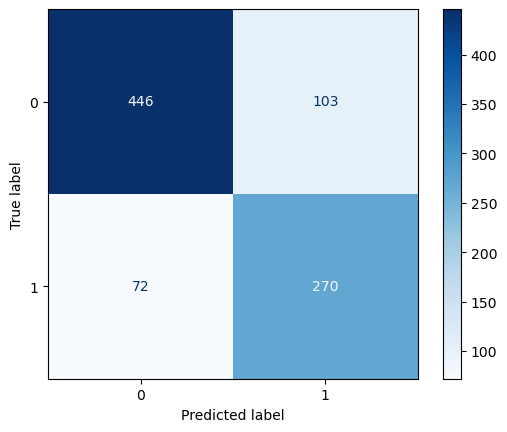

Model [SVM]:
+ params = {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
+ acc = [0.8268156424581006, 0.8202247191011236, 0.8314606741573034, 0.8258426966292135, 0.8539325842696629]
+ mean_acc = 0.831655 +/- 0.011698

Confusion matrix on training set for [SVM]:


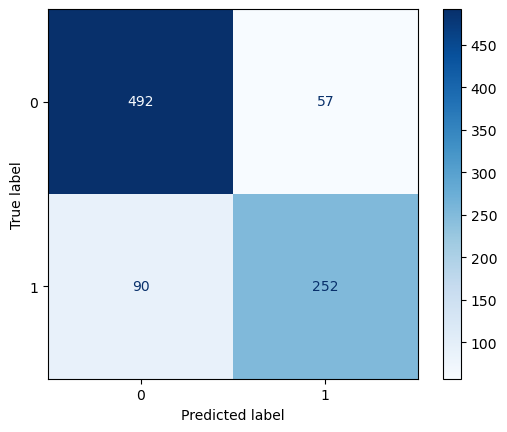

In [ ]:

# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
baseline_results = {}

# khởi tạo các tham số mặc định
baseline_models['LR']   = LogisticRegression(random_state=params["random_state"])
baseline_models['LDA']  = LinearDiscriminantAnalysis()
baseline_models['KNN']  = KNeighborsClassifier()
baseline_models['CART'] = DecisionTreeClassifier(random_state=params["random_state"])
baseline_models['NB']   = GaussianNB()
baseline_models['SVM']  = SVC(random_state=params["random_state"])

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    baseline_results[model_name] = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = StratifiedKFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    # Tách X_train, y_train thành 2 tập train, valid trên từng fold
    # Với mỗi fold, train cho huấn luyện, valid cho lượng giá và điều chỉnh tham số
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
        # Chia 2 tập thành train/valid
        X1_train, y1_train = X_train[train_idx], y_train[train_idx]
        X1_valid, y1_valid = X_train[valid_idx], y_train[valid_idx]


        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])

        # Huấn luyện mô hình
        model_clf.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = model_clf.predict(X1_valid)

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)
        

        # Lưu metrics trên từng fold
        baseline_results[model_name].append(valid_acc)

        pass # fold
    # Chúng ta đơn giản sử dụng lệnh bên dưới thay cho khối lệnh k-fold bên trên
    # baseline_results[name] = cross_val_score(model_clf, X_train, y_train, cv = kfold, scoring="accuracy")

    # hiển thị tham số mô hình
    print(f'+ params = {baseline_models[model_name].get_params()}')

    # hiển thị kết quả trên từng fold
    print(f'+ acc = {baseline_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold,
    # std: độ lệch chuẩn=> nếu cùng mean thì độ lệch nào nhỏ hơn thì tốt hơn vì ổn định và tập trung hơn
    s_msg = f'+ mean_acc = {np.mean(baseline_results[model_name]):.6f} +/- {np.std(baseline_results[model_name]):.6f}'
    print(s_msg)
    print()

    # Huấn luyện lại với trên toàn bộ dữ liệu train (re-fit all train_data)
    baseline_models[model_name].fit(X_train, y_train)

    y_pred_train = baseline_models[model_name].predict(X_train)
    cm = confusion_matrix(y_train, y_pred_train)
    print(f'Confusion matrix on training set for [{model_name}]:')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    
    disp.plot(cmap='Blues')
    plt.show() 

**Nhận xét**:
- Mô hình Tốt nhất: 
    - SVM dẫn đầu với độ chính xác trung bình cao nhất là 0.831655.
    - Mặc dù không phải là mô hình ổn định nhất (độ lệch chuẩn cao hơn NB), nhưng độ lệch chuẩn chỉ là $\pm 0.0117$, vẫn cho thấy hiệu suất cao và khá ổn định.
    - Mô hình này đạt độ chính xác cao nhất trong một fold là $0.8539$.
- Mô hình Ổn định nhất: 
    - Naive Bayes (NB) có độ lệch chuẩn thấp nhất, chỉ $\pm 0.007973$, chứng tỏ mô hình này rất ổn định trên các tập dữ liệu huấn luyện/kiểm tra khác nhau, mặc dù độ chính xác trung bình chỉ ở mức $0.796868$.
- Mô hình Kém nhất: 
    - CART thể hiện hiệu suất yếu nhất, độ chính xác trung bình thấp nhất: 0.775532. Độ lệch chuẩn cao nhất: $\pm 0.029088$, cho thấy mô hình kém ổn định và nhạy cảm với dữ liệu.
-   Các mô hình còn lại LR và KNN có hiệu suất tương đương nhau (khoảng $0.804$), nằm ở mức trung bình tốt.LDA có độ chính xác thấp hơn một chút ($0.799121$) nhưng độ biến thiên cao.

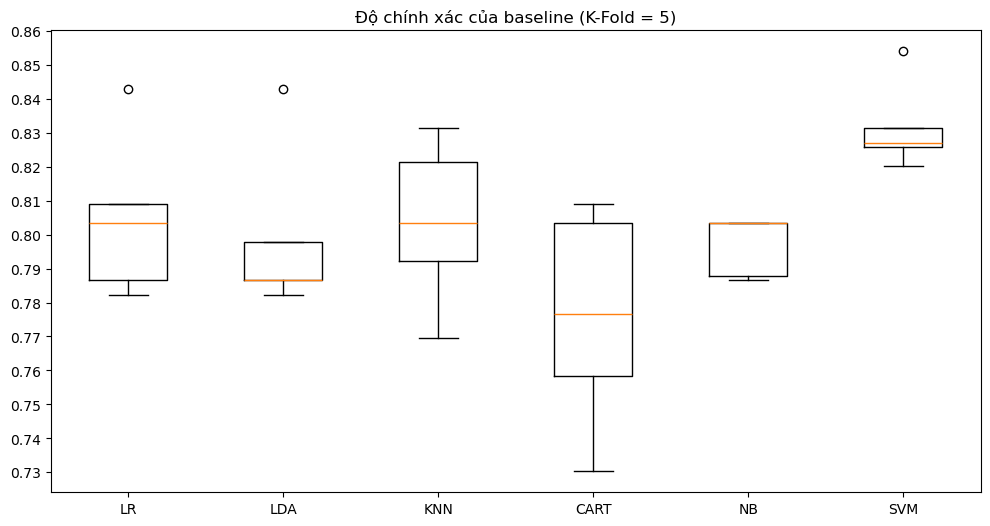

In [11]:
# In biểu đồ box-plot trên độ chính xác với k-fold
plt.figure(figsize=(12,6))
plt.boxplot(baseline_results.values())
plt.gca().set_xticklabels(baseline_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params["k_fold"]})')
plt.show()

**Nhận xét**:
- Mô hình Tốt nhất (The Best): SVM có độ chính xác trung vị cao nhất ($\approx 0.828$) và phạm vi phân tán hẹp, cho thấy hiệu suất tốt và ổn định.
- Mô hình Kém nhất (The Worst): CART có độ chính xác trung vị thấp nhất ($\approx 0.778$) và độ biến thiên (phạm vi hộp) lớn nhất, cho thấy hiệu suất thấp và thiếu ổn định.
- Mô hình Ổn định (Stable): LR, LDA, NB, và SVM đều thể hiện sự ổn định với khoảng $\text{IQR}$ hẹp, đặc biệt là SVM ở mức độ chính xác cao.
- Mô hình Có Độ Biến Thiên Cao (High Variance): CART và KNN (mặc dù KNN có hiệu suất trung bình tốt hơn).

### 6.2. Tinh chỉnh mô hình (Tuning Models)

Model [LR]:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
+ Best score: 0.804727
+ Best tuning params: {'penalty': 'l1', 'class_weight': None, 'C': 10.0}
+ Best full params: {'C': 10.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Confusion matrix on training set for [LR]:


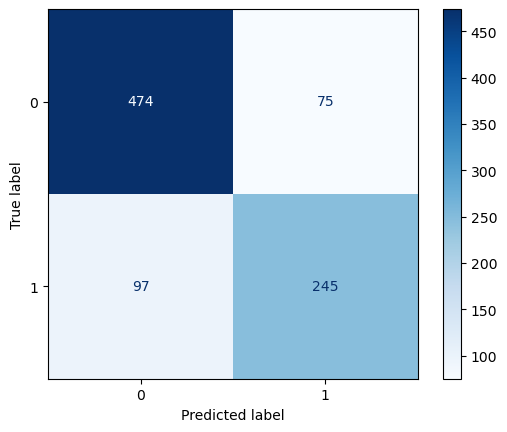

Model [SVM]:
Fitting 5 folds for each of 10 candidates, totalling 50 fits
+ Best score: 0.801368
+ Best tuning params: {'loss': 'squared_hinge', 'C': 0.1}
+ Best full params: {'C': 0.1, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 10000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}

Confusion matrix on training set for [SVM]:


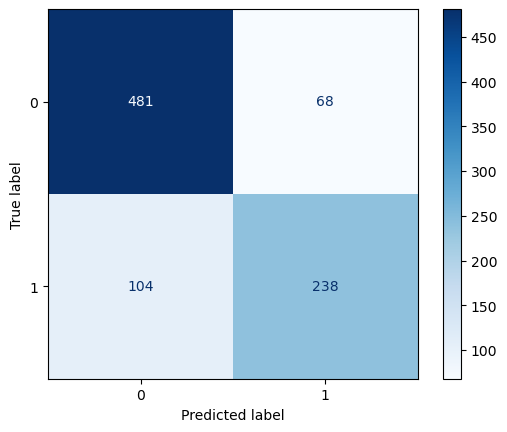

Hoàn thành quá trình tìm kiếm tham số tối ưu cho LR và LinearSVC!


In [33]:
from sklearn.svm import LinearSVC

tunning_results = {
    "best_clf": {},
    "best_score": {},
}

tunning_models = {}
tunning_params = {}

# --- 1. Mô hình LR ---
tunning_models['LR'] = LogisticRegression(
    random_state=params["random_state"],
    solver='liblinear'  # hỗ trợ penalty l1 và l2
)
tunning_params['LR'] = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced']
}

# --- 2. Mô hình LinearSVC (thay SVM) ---
tunning_models['SVM'] = LinearSVC(
    random_state=params["random_state"],
    max_iter=10000  # đảm bảo hội tụ
)
tunning_params['SVM'] = {
    'C': [0.01, 0.1, 1, 10, 50],
    'loss': ['hinge', 'squared_hinge']
}

# --- 3. RandomizedSearchCV cho từng mô hình ---
for model_name in tunning_models:
    model_clf = tunning_models[model_name]

    print(f'Model [{model_name}]:')
    kfold = StratifiedKFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    random_clf = RandomizedSearchCV(
        estimator=model_clf,
        param_distributions=tunning_params[model_name],
        n_iter=20,       # giảm số lần thử để chạy nhanh
        cv=kfold,
        scoring="accuracy",
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    grid_result = random_clf.fit(X_train, y_train)

    # --- Lưu kết quả ---
    tunning_results["best_clf"][model_name] = random_clf.best_estimator_
    tunning_results["best_score"][model_name] = grid_result.best_score_

    print(f'+ Best score: {grid_result.best_score_:.6f}')
    print(f'+ Best tuning params: {random_clf.best_params_}')
    print(f'+ Best full params: {random_clf.best_estimator_.get_params()}')
    print()
    y_pred_train = random_clf.best_estimator_.predict(X_train)
    cm = confusion_matrix(y_train, y_pred_train)
    print(f'Confusion matrix on training set for [{model_name}]:')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap='Blues')
    plt.show()

print("Hoàn thành quá trình tìm kiếm tham số tối ưu cho LR và LinearSVC!")



## 7. Kiểm nghiệm kết quả trên Test (Finalize Model)

### Load và tiền xử lý tập test


In [27]:
# Load
df_test = pd.read_csv(f'{params["exps_dir"]}/data/test_preprocessed.csv')
print("Test: ", len(df_test))
display.display(df_test.head())

Test:  418


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,892,3,1,34.5,0,0,7.8292,1,1,0,2
1,893,3,0,47.0,1,0,7.0000,2,2,3,3
2,894,2,1,62.0,0,0,9.6875,1,1,0,2
3,895,3,1,27.0,0,0,8.6625,2,1,0,2
4,896,3,0,22.0,1,1,12.2875,2,3,3,3


In [28]:
# Standard Encoder
standard_scaler = joblib.load(f'{params["exps_dir"]}/feature1/standard_scaler.joblib')
display.display(standard_scaler.__dict__)

scale_columns = dict(np.load(f'{params["exps_dir"]}/feature1/scale_columns.npz'))['scale_columns']
print(scale_columns)

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Age', 'Fare', 'Parch', 'SibSp', 'FamilySize'], dtype=object),
 'n_features_in_': 5,
 'n_samples_seen_': np.int64(891),
 'mean_': array([29.36158249, 32.20420797,  0.38159371,  0.52300786,  1.90460157]),
 'var_': array([1.69322249e+02, 2.46666531e+03, 6.48999031e-01, 1.21467827e+00,
        2.60032675e+00]),
 'scale_': array([13.01238827, 49.66553444,  0.80560476,  1.10212444,  1.61255287])}

['Age' 'Fare' 'Parch' 'SibSp' 'FamilySize']


In [29]:
df_test.drop(columns=["PassengerId"], inplace=True) #loại bỏ cột PassengerId trước khi scale
df_test[scale_columns] = standard_scaler.transform(df_test[scale_columns])
display.display(df_test.head())


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,3,1,0.394887,-0.474545,-0.473674,-0.490783,1,-0.560975,0,2
1,3,0,1.355510,0.432793,-0.473674,-0.507479,2,0.059160,3,3
2,2,1,2.508257,-0.474545,-0.473674,-0.453367,1,-0.560975,0,2
3,3,1,-0.181487,-0.474545,-0.473674,-0.474005,2,-0.560975,0,2
4,3,0,-0.565736,0.432793,0.767630,-0.401017,2,0.679295,3,3


In [ ]:
# Chia dữ liệu thành trường input/output

#X_test = df_test.drop(columns=["Survived"]).values
#y_test = df_test["Survived"].values.astype(int)


KeyError: "['Survived'] not found in axis"

In [31]:
# Giả sử df_test chỉ có features (X_test)
X_test = df_test.values  # hoặc chọn đúng columns như X_train

# Lưu kết quả dự đoán
predictions = {}

for model_name in baseline_models:
    model_clf = baseline_models[model_name]
    
    # Dự đoán
    y_pred_test = model_clf.predict(X_test)
    
    # Lưu vào dictionary
    predictions[model_name] = y_pred_test
    
    print(f'Predictions for [{model_name}]:')
    print(y_pred_test[:20])  # xem 20 mẫu đầu tiên


Predictions for [LR]:
[0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1]
Predictions for [LDA]:
[0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1]
Predictions for [KNN]:
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]
Predictions for [CART]:
[0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1]
Predictions for [NB]:
[1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1]
Predictions for [SVM]:
[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1]


## Đánh giá Baseline

Baseline [LR]
+ acc = 0.800


array([[471,  78],
       [100, 242]])

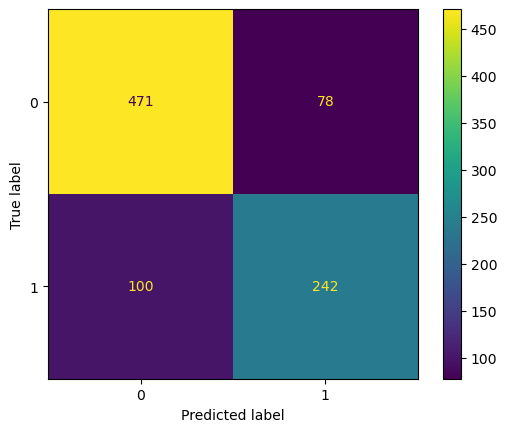

Baseline [LDA]
+ acc = 0.802


array([[477,  72],
       [104, 238]])

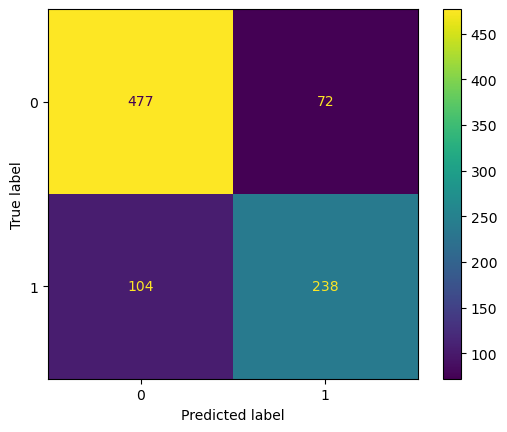

Baseline [KNN]
+ acc = 0.864


array([[501,  48],
       [ 73, 269]])

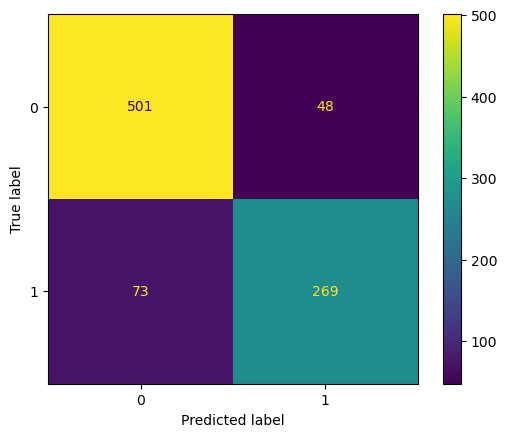

Baseline [CART]
+ acc = 0.982


array([[547,   2],
       [ 14, 328]])

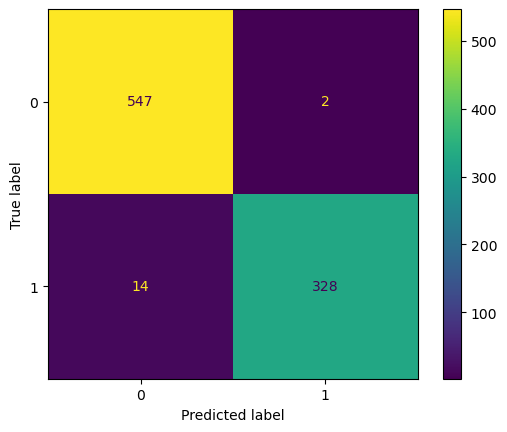

Baseline [NB]
+ acc = 0.804


array([[446, 103],
       [ 72, 270]])

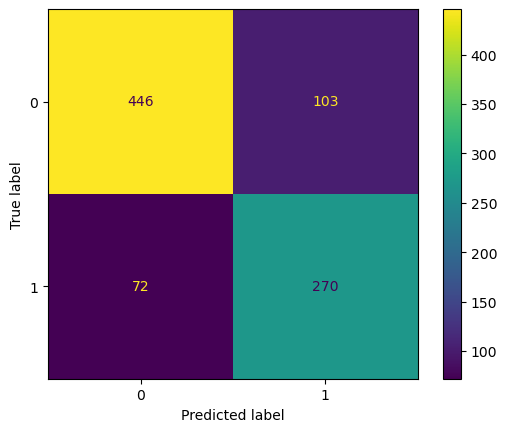

Baseline [SVM]
+ acc = 0.835


array([[492,  57],
       [ 90, 252]])

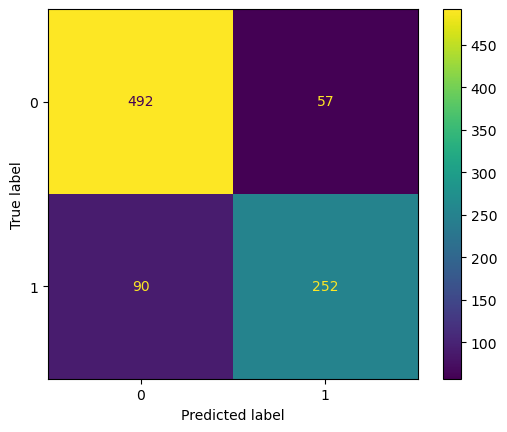

In [ ]:
test_models  = {}
test_scores  = {}

# Kiểm tra kết quả trên tập test (baseline)
for model_name in baseline_models:
    model_clf = baseline_models[model_name]
    y_pred_test = model_clf.predict(df_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    # information
    print(f'Baseline [{model_name}]')
    print(f'+ acc = {test_acc:.3f}')

    cm = confusion_matrix(y_test, y_pred_test)
    display.display(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot()

    plt.show()

Tunning [KNN]
+ acc = 0.827


array([[505,  44],
       [110, 232]])

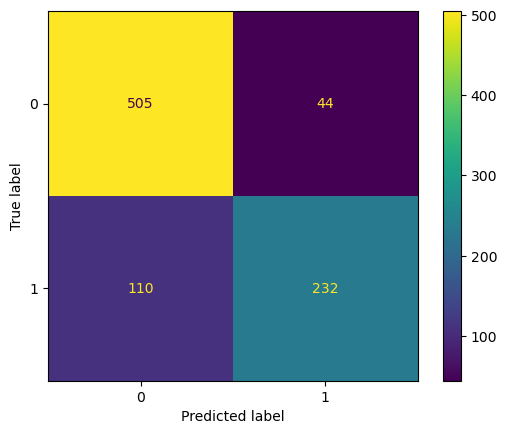

Tunning [SVM]
+ acc = 0.790


array([[470,  79],
       [108, 234]])

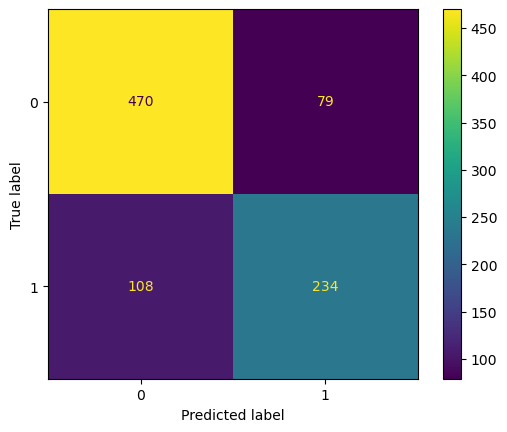

In [34]:
# Kiểm tra kết quả trên tập test (baseline)
for model_name in tunning_models:
    model_clf = tunning_results["best_clf"][model_name]
    y_pred_test = model_clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    # information
    print(f'Tunning [{model_name}]')
    print(f'+ acc = {test_acc:.3f}')

    cm = confusion_matrix(y_test, y_pred_test)
    display.display(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot()

    plt.show()

## 8. Lưu kết quả thí nghiệm

In [ ]:
save_dir = params["save_dir"]
!jupyter nbconvert $cur_dir/model1.ipynb \
    --to html \
    --output-dir $save_dir \
    --output model1